# EDA Insights

This notebook is a synthesis notebook. It does not repeat the full exploratory workflow from notebooks `02` to `10`. Instead, it consolidates the most important findings for modeling, business interpretation, and final project reporting.


In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

PROJECT_ROOT = Path("..").resolve()
REPORTS_TABLES_DIR = PROJECT_ROOT / "reports" / "tables"
REPORTS_FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

NOTEBOOK_TABLES_DIR = REPORTS_TABLES_DIR / "11_eda_insights"
NOTEBOOK_FIGURES_DIR = REPORTS_FIGURES_DIR / "11_eda_insights"
NOTEBOOK_TABLES_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Tables dir  : {NOTEBOOK_TABLES_DIR}")
print(f"Figures dir : {NOTEBOOK_FIGURES_DIR}")


Tables dir  : /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/11_eda_insights
Figures dir : /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/figures/11_eda_insights


## 1. Objectives

- Summarize the most important insights from data loading, validation, cleaning, analysis, feature engineering, outlier review, and feature selection.
- Highlight which findings materially affect fraud modeling.
- Create a concise set of presentation-ready insights for viva, grading, and final project communication.


In [2]:
duplicate_summary = pd.read_csv(REPORTS_TABLES_DIR / "04_data_cleaning" / "duplicate_removal_summary.csv")
missing_validation = pd.read_csv(REPORTS_TABLES_DIR / "03_data_validation" / "missing_value_validation.csv")
target_distribution = pd.read_csv(REPORTS_TABLES_DIR / "05_univariate_analysis" / "target_distribution_after_cleaning.csv")
amount_summary = pd.read_csv(REPORTS_TABLES_DIR / "05_univariate_analysis" / "amount_summary.csv")
corr_target = pd.read_csv(REPORTS_TABLES_DIR / "06_bivariate_analysis" / "correlation_with_target.csv")
outlier_recommendations = pd.read_csv(REPORTS_TABLES_DIR / "09_outlier_analysis" / "outlier_handling_recommendations.csv")
feature_selection = pd.read_csv(REPORTS_TABLES_DIR / "10_feature_selection" / "feature_selection_decisions.csv")
selected_features = pd.read_csv(REPORTS_TABLES_DIR / "10_feature_selection" / "selected_feature_list.csv")
amount_resolution = pd.read_csv(REPORTS_TABLES_DIR / "10_feature_selection" / "amount_feature_resolution.csv")

top_corr_target = corr_target.assign(abs_correlation_with_class=corr_target["correlation_with_class"].abs()).sort_values(
    "abs_correlation_with_class",
    ascending=False,
)

duplicate_summary


,metric,value
0,rows_before_cleaning,284807.0000
1,rows_after_cleaning,283726.0000
2,rows_removed_as_exact_duplicates,1081.0000
3,remaining_duplicates,0.0000
4,fraud_rate_before_percent,0.1727
5,fraud_rate_after_percent,0.1667


## 2. Data Quality Insights

The main project-level data quality findings are summarized below. These are the checks that matter most for downstream fraud modeling.


In [3]:
duplicate_lookup = duplicate_summary.set_index("metric")["value"].to_dict()
fraud_row = target_distribution.loc[target_distribution["Class"] == 1].iloc[0]

data_quality_summary = pd.DataFrame(
    [
        {
            "insight_area": "Missing values",
            "key_finding": "No missing values were detected across the validated columns.",
            "evidence": f"Maximum missing percent = {missing_validation['missing_percent'].max():.1f}%",
            "modeling_implication": "No imputation step is required before baseline modeling."
        },
        {
            "insight_area": "Duplicates",
            "key_finding": "Exact duplicate transactions were removed before modeling.",
            "evidence": f"Rows removed = {int(duplicate_lookup['rows_removed_as_exact_duplicates'])}",
            "modeling_implication": "Removing duplicates reduces leakage risk and avoids overweighting repeated patterns."
        },
        {
            "insight_area": "Class imbalance",
            "key_finding": "Fraud remains extremely rare after cleaning.",
            "evidence": f"Fraud count = {int(fraud_row['count'])}, fraud rate = {fraud_row['percent']:.4f}%",
            "modeling_implication": "Accuracy alone is misleading; threshold-sensitive fraud metrics are required."
        },
        {
            "insight_area": "Amount distribution",
            "key_finding": "Transaction amount is strongly right-skewed.",
            "evidence": f"Amount skewness = {amount_summary.loc[0, 'skewness']:.2f}",
            "modeling_implication": "A transformed amount representation is more stable than raw amount."
        },
    ]
)

data_quality_summary.to_csv(NOTEBOOK_TABLES_DIR / "data_quality_insights_summary.csv", index=False)
data_quality_summary


,insight_area,key_finding,evidence,modeling_implication
0,Missing values,No missing values were detected across the val...,Maximum missing percent = 0.0%,No imputation step is required before baseline...
1,Duplicates,Exact duplicate transactions were removed befo...,Rows removed = 1081,Removing duplicates reduces leakage risk and a...
2,Class imbalance,Fraud remains extremely rare after cleaning.,"Fraud count = 473, fraud rate = 0.1667%",Accuracy alone is misleading; threshold-sensit...
3,Amount distribution,Transaction amount is strongly right-skewed.,Amount skewness = 16.98,A transformed amount representation is more st...


## 3. Signal Insights

The strongest fraud signal is carried by a relatively small subset of PCA-derived variables and engineered interaction features. Raw `Time` and `Amount` are much weaker on their own.


In [4]:
signal_summary = pd.DataFrame(
    [
        {
            "insight_area": "Top bivariate signals",
            "key_finding": "PCA variables such as V17, V14, V12, V10, and V11 show the strongest direct fraud relationships.",
            "evidence": ", ".join(top_corr_target.head(5).index.astype(str)),
            "modeling_implication": "Baseline models should prioritize PCA-driven signal over raw contextual variables."
        },
        {
            "insight_area": "Outliers",
            "key_finding": "Many outlier regions are fraud-enriched rather than pure noise.",
            "evidence": outlier_recommendations.iloc[0]["recommended_action"],
            "modeling_implication": "Outliers should generally be preserved because they carry anomaly signal."
        },
        {
            "insight_area": "Feature engineering",
            "key_finding": "Interaction features strengthened joint fraud signal, but correlated groups needed pruning.",
            "evidence": ", ".join(selected_features.head(5)["feature"].tolist()),
            "modeling_implication": "Engineered features help, but redundancy control is required for interpretability and model stability."
        },
        {
            "insight_area": "Amount family",
            "key_finding": "The amount family was resolved to a single transformed representation.",
            "evidence": amount_resolution.iloc[0]["final_amount_family_decision"],
            "modeling_implication": "`log_amount` is retained while raw amount and ratio variants are dropped."
        },
    ]
)

signal_summary.to_csv(NOTEBOOK_TABLES_DIR / "signal_insights_summary.csv", index=False)
signal_summary


,insight_area,key_finding,evidence,modeling_implication
0,Top bivariate signals,"PCA variables such as V17, V14, V12, V10, and ...","29, 28, 27, 26, 25",Baseline models should prioritize PCA-driven s...
1,Outliers,Many outlier regions are fraud-enriched rather...,Preserve outliers; tail region is meaningfully...,Outliers should generally be preserved because...
2,Feature engineering,Interaction features strengthened joint fraud ...,"V14_V12_interaction, V14, V17_V16_interaction,...","Engineered features help, but redundancy contr..."
3,Amount family,The amount family was resolved to a single tra...,KEEP_AS_FINAL_AMOUNT_FEATURE,`log_amount` is retained while raw amount and ...


## 4. Final Selected Feature Set

The selected features below summarize the final modeling-ready feature space after relevance, redundancy, and model-aware review.


In [5]:
selected_features


,feature,feature_category,selection_decision,selection_reason
0,V14_V12_interaction,INTERACTION,KEEP,Shows strong fraud relevance and remains compe...
1,V14,PCA,KEEP,Shows strong fraud relevance and remains compe...
2,V17_V16_interaction,INTERACTION,KEEP,Shows strong fraud relevance and remains compe...
3,V12,PCA,KEEP,Shows strong fraud relevance and remains compe...
4,V17,PCA,KEEP,Shows strong fraud relevance and remains compe...
5,V10,PCA,KEEP,Shows strong fraud relevance and remains compe...
6,V4,PCA,KEEP,Shows strong fraud relevance and remains compe...
7,V16,PCA,KEEP,Shows strong fraud relevance and remains compe...
8,V3,PCA,KEEP,Shows strong fraud relevance and remains compe...
9,V11,PCA,KEEP,Shows strong fraud relevance and remains compe...


## 5. Visual Recap

These visuals are reused from the earlier notebooks and reports because this notebook is intended to synthesize, not regenerate, the full exploratory workflow.


### Class Imbalance After Validation

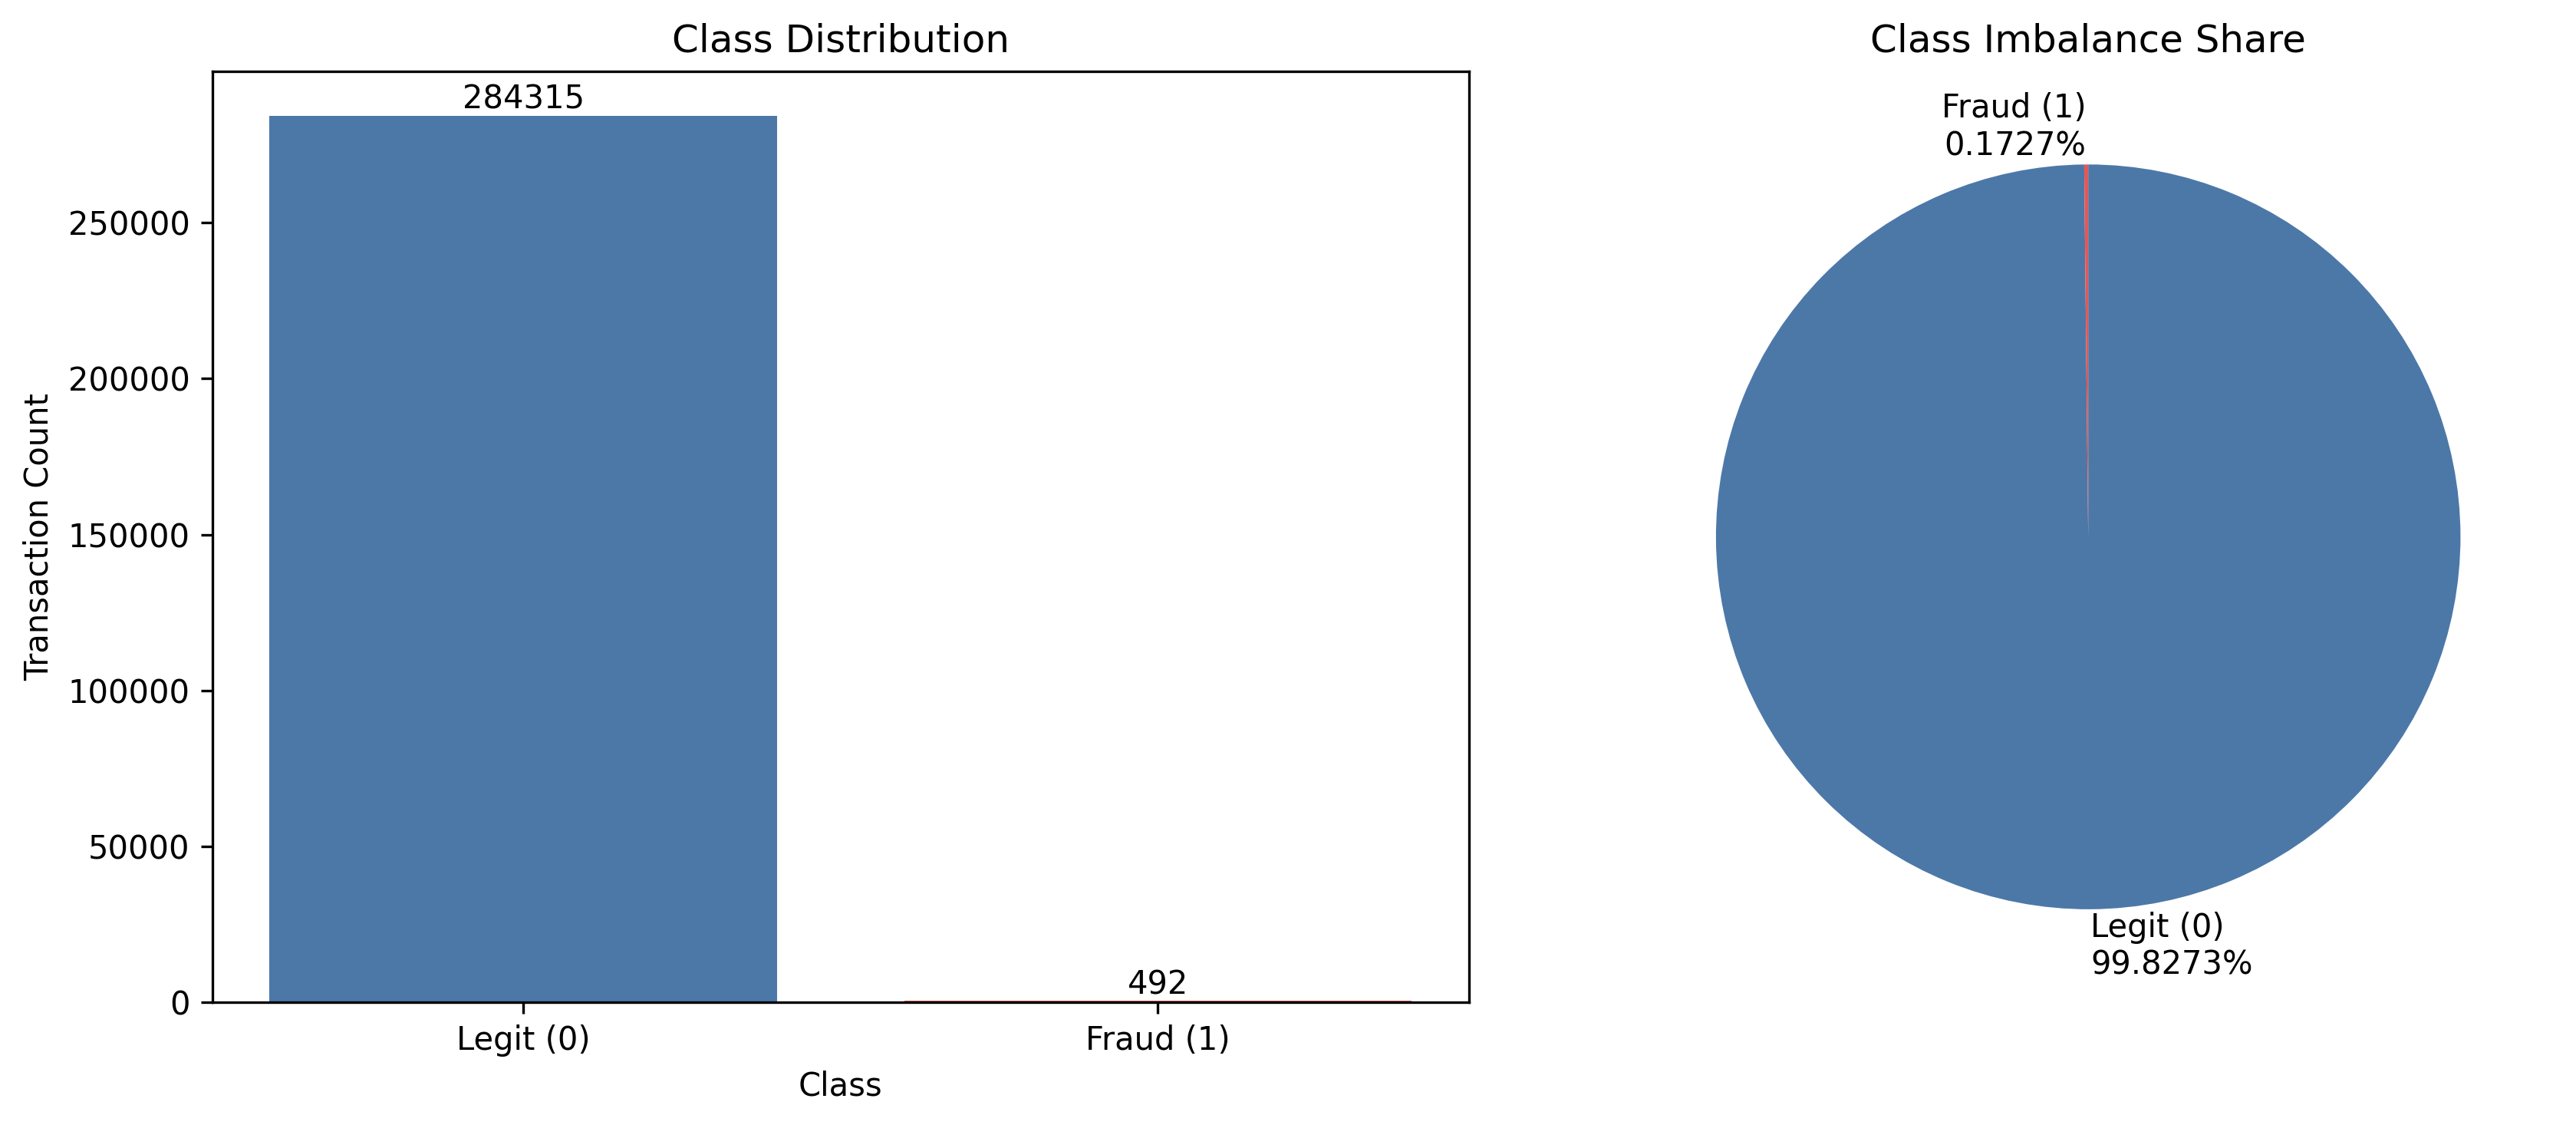

### Top Feature Correlations With Fraud

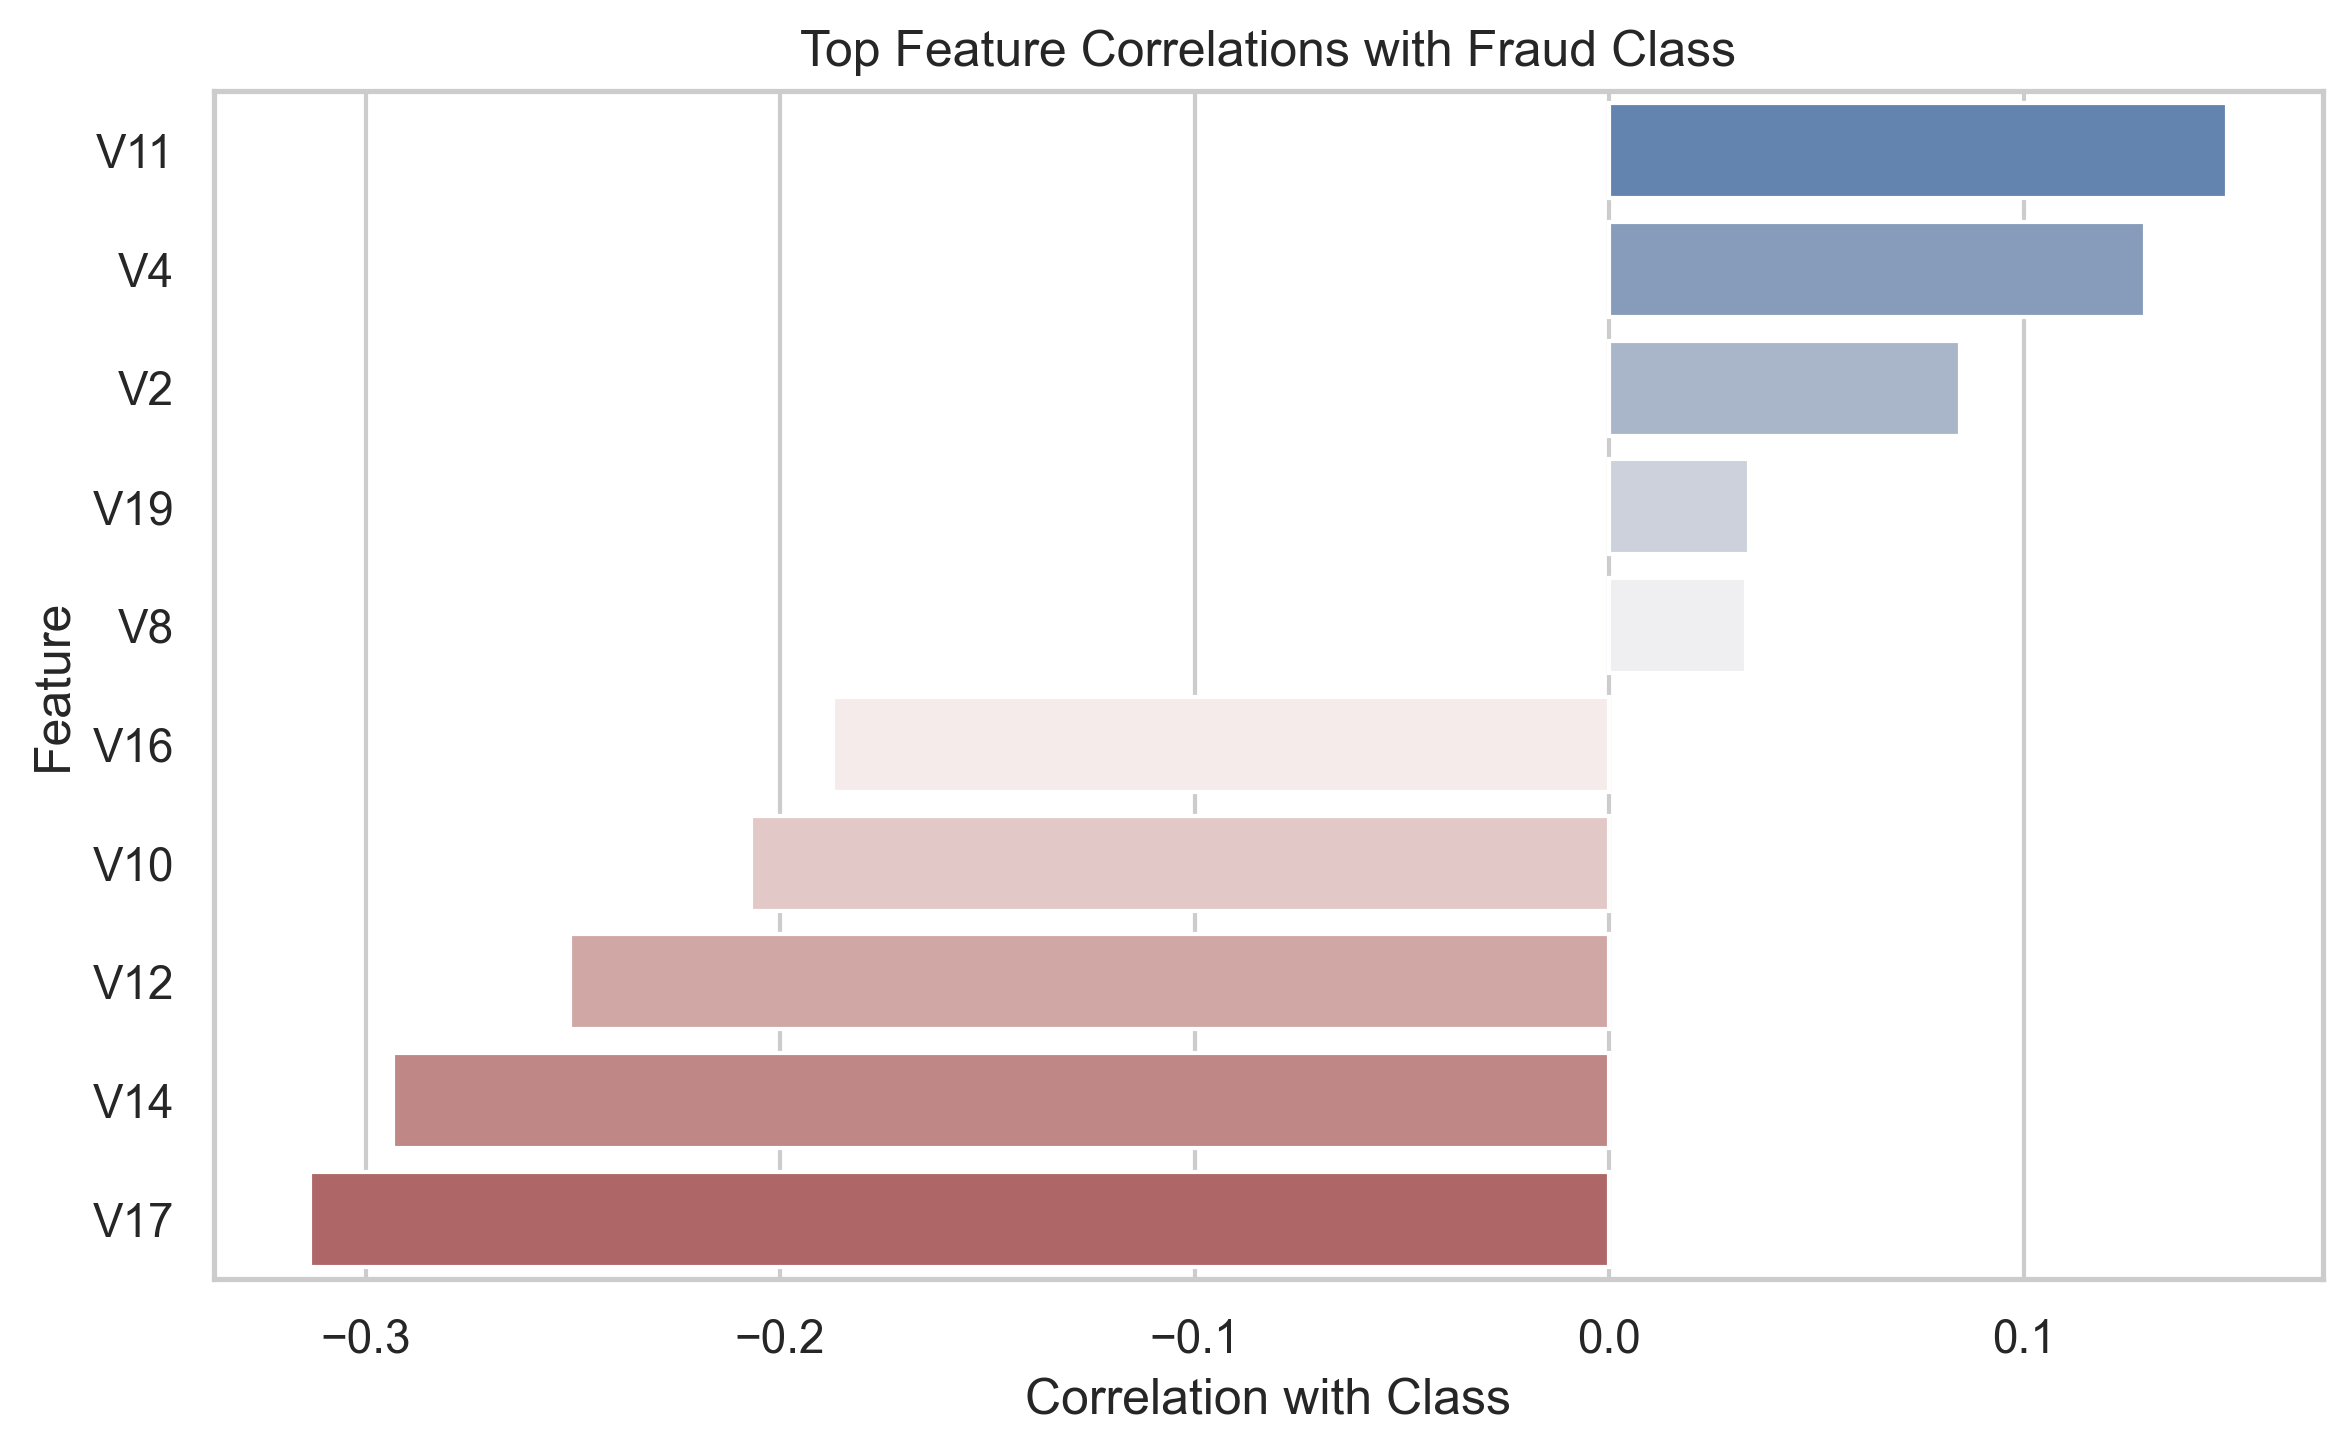

### Priority Feature Correlation Heatmap

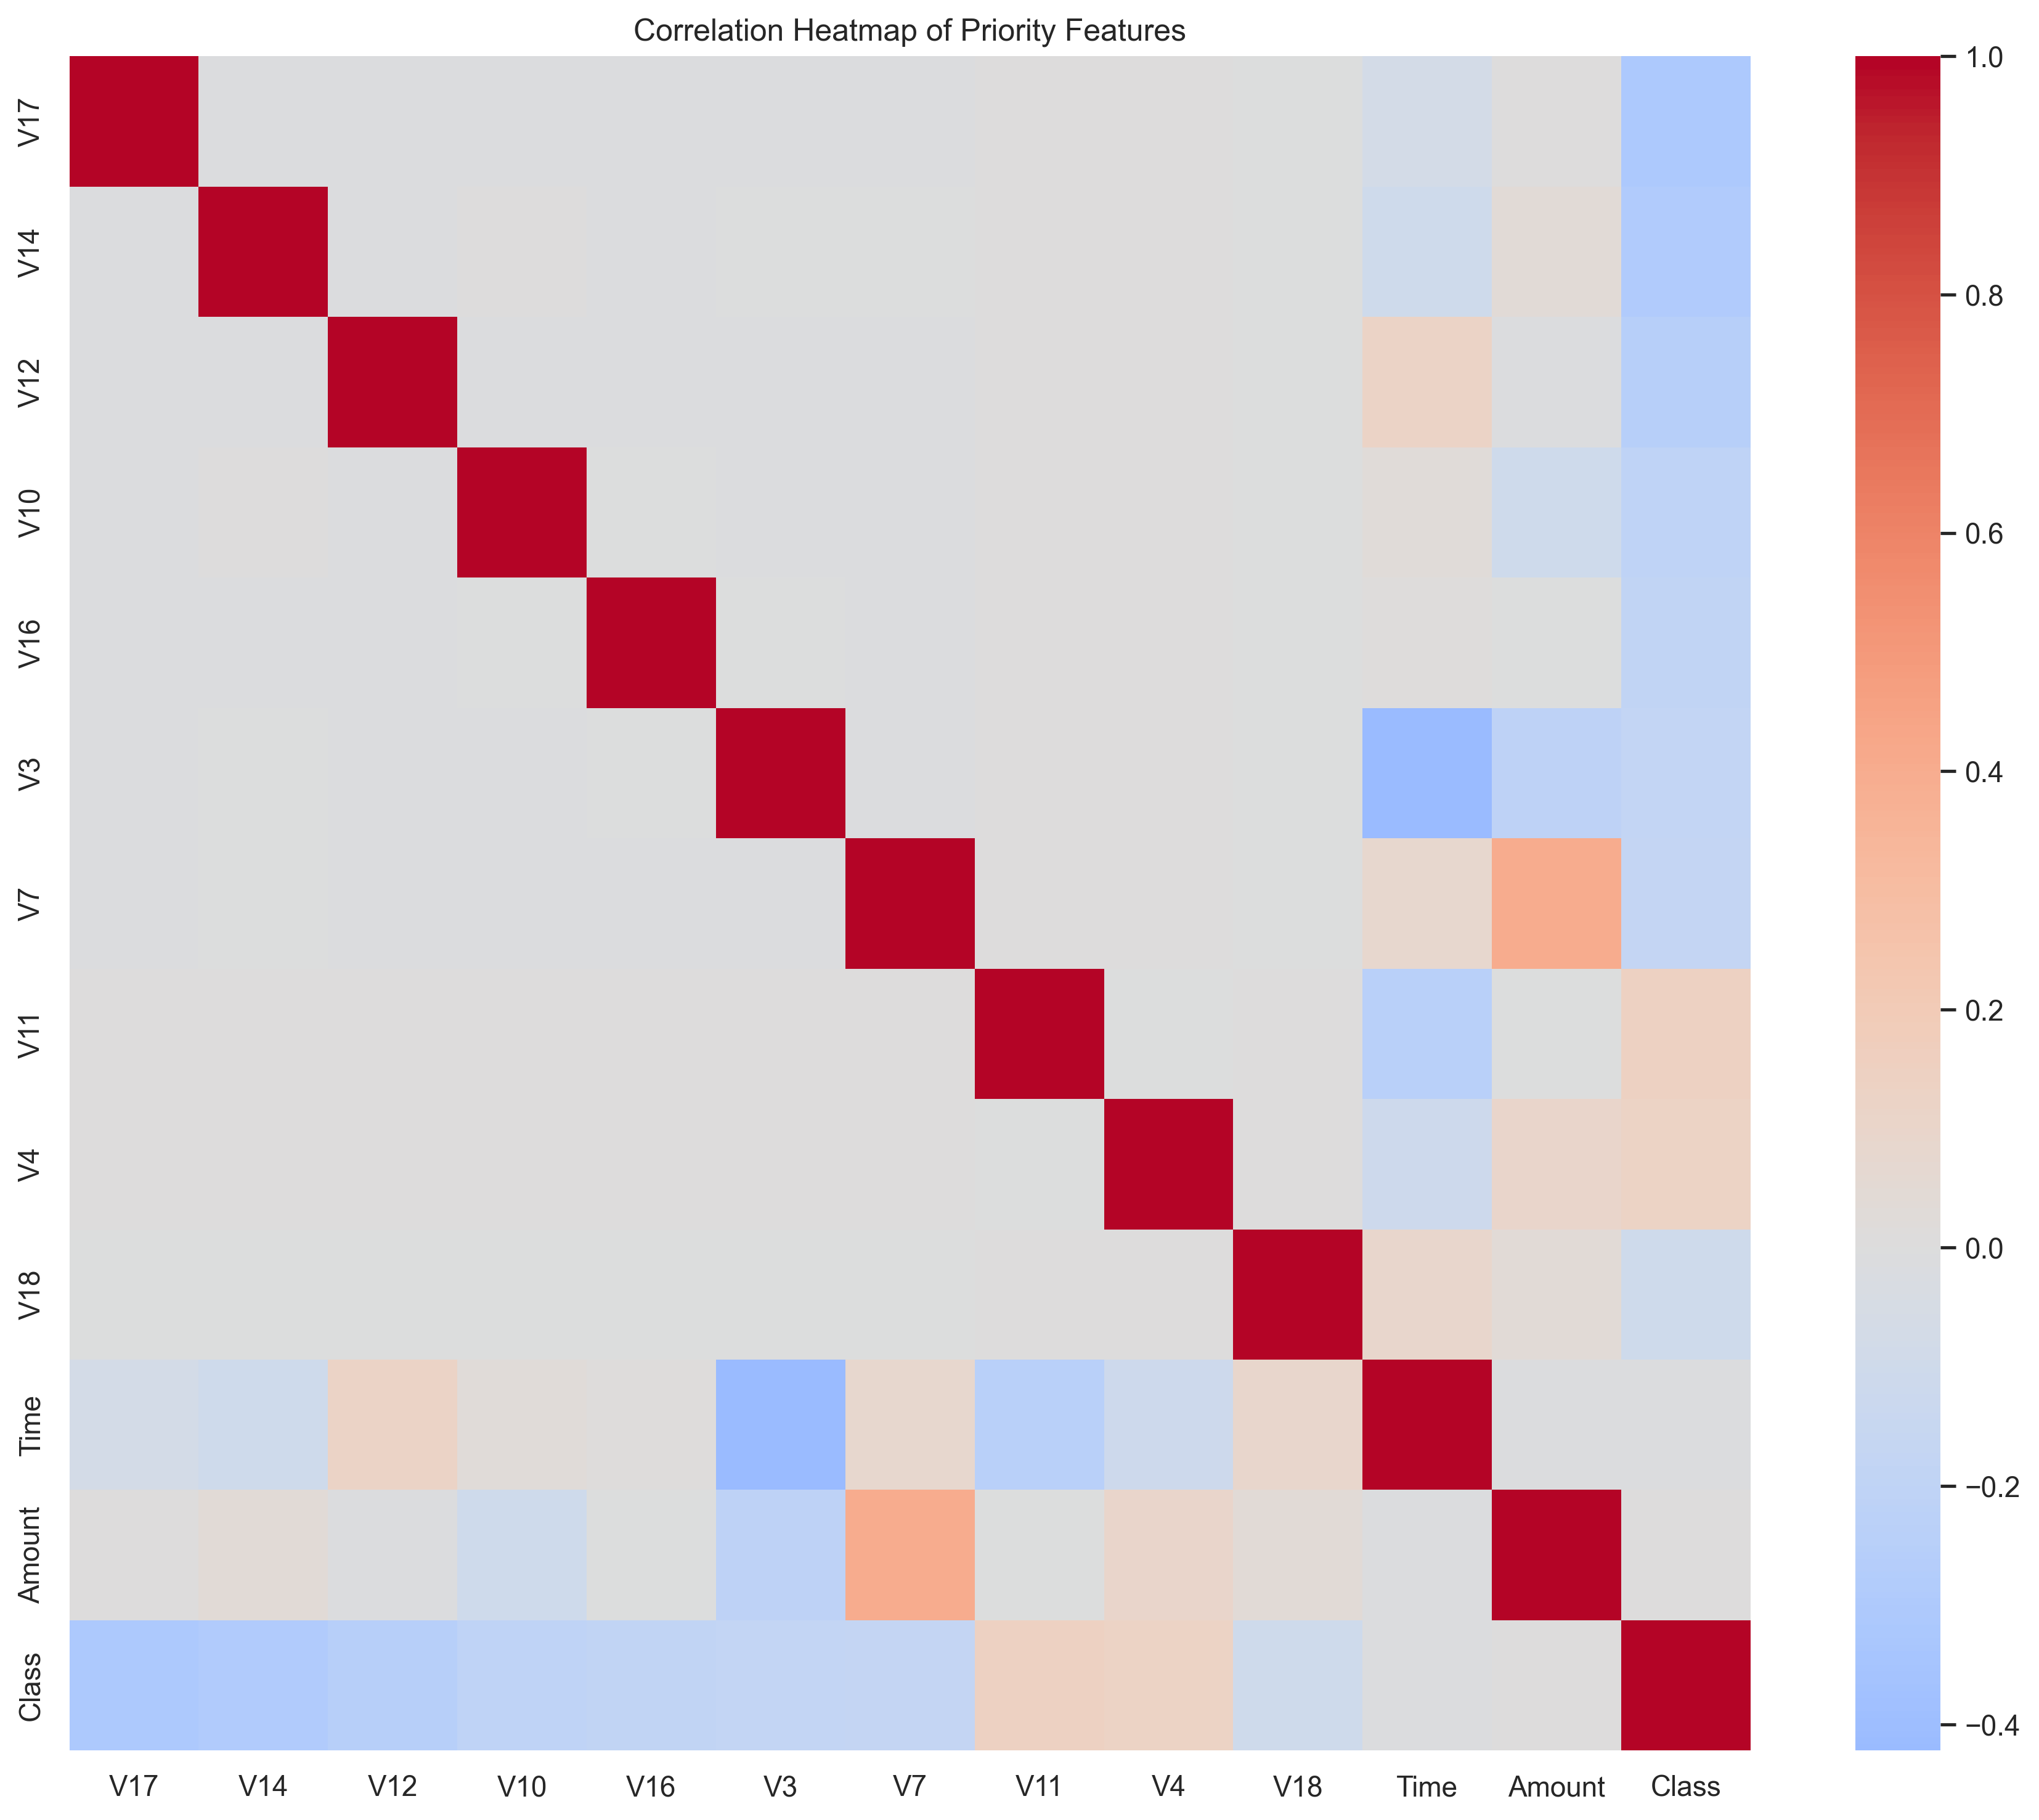

### Feature Selection Outcomes By Category

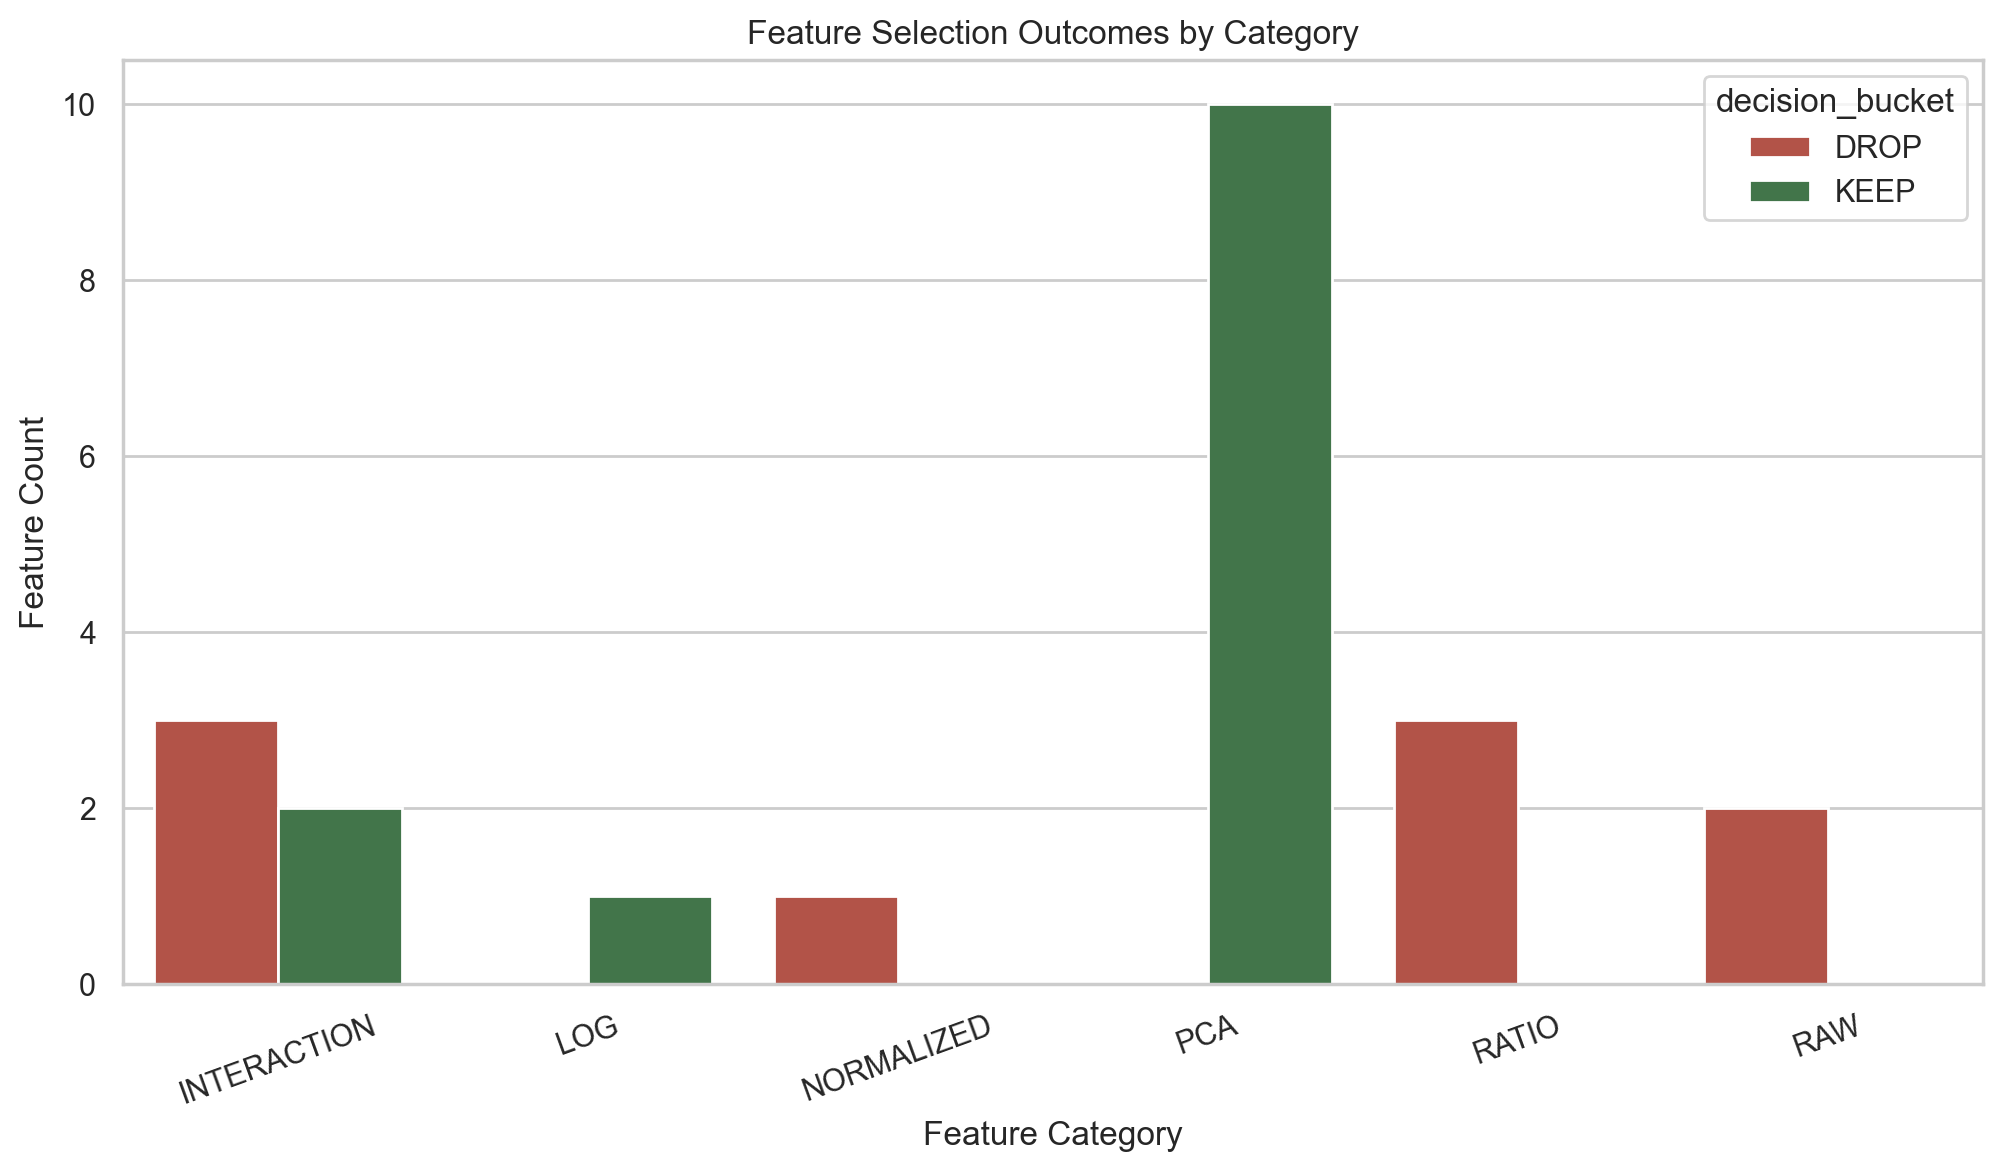

In [6]:
visuals = [
    (
        "Class Imbalance After Validation",
        REPORTS_FIGURES_DIR / "03_data_validation" / "class_imbalance_visualization.png",
    ),
    (
        "Top Feature Correlations With Fraud",
        REPORTS_FIGURES_DIR / "06_bivariate_analysis" / "top_feature_correlations_with_class.png",
    ),
    (
        "Priority Feature Correlation Heatmap",
        REPORTS_FIGURES_DIR / "07_multivariate_analysis" / "priority_feature_correlation_heatmap.png",
    ),
    (
        "Feature Selection Outcomes By Category",
        REPORTS_FIGURES_DIR / "10_feature_selection" / "feature_selection_decision_by_category.png",
    ),
]

for title, path in visuals:
    display(Markdown(f"### {title}"))
    if path.exists():
        display(Image(filename=str(path), width=900))
    else:
        display(Markdown(f"Figure missing: `{path}`"))


## 6. Modeling and Business Implications

- Fraud is highly imbalanced, so threshold tuning and fraud-focused metrics matter more than accuracy.
- PCA features carry most of the direct predictive signal, which makes them the core input space for baseline models.
- Outliers are often meaningful and should not be removed blindly.
- `log_amount` is a better amount representation than raw `Amount`, but transaction size remains a secondary signal compared with the strongest PCA components.
- The final feature set is appropriate for Logistic Regression because the most problematic redundant predictors were removed.
- The same feature set is also appropriate for tree models because it still preserves strong non-linear and interaction-based fraud patterns.
- The next stage should focus on model comparison, fraud-focused threshold selection, and practical `BLOCK`, `REVIEW`, and `APPROVE` style decision rules.


In [7]:
final_insights = pd.DataFrame(
    {
        "final_takeaway": [
            "Fraud is extremely rare, so the project must evaluate models with imbalance-aware metrics.",
            "PCA-derived variables carry most of the strongest predictive signal in this dataset.",
            "Outlier regions are often fraud-enriched and should mostly be preserved.",
            "Redundant engineered features were pruned to improve interpretability and reduce multicollinearity risk.",
            "`log_amount` is the retained amount-family feature; raw amount and ratio variants were dropped.",
            "The final selected feature set is modeling-ready for both Logistic Regression and tree baselines.",
        ]
    }
)

final_insights.to_csv(NOTEBOOK_TABLES_DIR / "final_eda_takeaways.csv", index=False)
final_insights


,final_takeaway
0,"Fraud is extremely rare, so the project must e..."
1,PCA-derived variables carry most of the strong...
2,Outlier regions are often fraud-enriched and s...
3,Redundant engineered features were pruned to i...
4,`log_amount` is the retained amount-family fea...
5,The final selected feature set is modeling-rea...


In [8]:
eda_insights_report = """# EDA Insights Report

## Purpose

This notebook consolidates the main insights from the exploratory analysis, feature engineering, outlier review, and feature selection stages.

## Main Insights

- The dataset is clean enough for modeling after duplicate removal, with no meaningful missing-value problem.
- Fraud is extremely rare, so threshold-aware and imbalance-aware evaluation is required.
- PCA-derived variables carry most of the strongest fraud signal.
- Outlier regions are often fraud-enriched and should generally be preserved.
- Feature engineering added useful interaction terms, but redundancy pruning was necessary.
- `log_amount` is the retained amount-family feature; raw `Amount` and amount ratios are dropped.
- The final selected feature set is suitable for both Logistic Regression and tree-based baseline models.

## Saved Tables

- `reports/tables/11_eda_insights/data_quality_insights_summary.csv`
- `reports/tables/11_eda_insights/signal_insights_summary.csv`
- `reports/tables/11_eda_insights/final_eda_takeaways.csv`
- `reports/tables/11_eda_insights/eda_insights_report.md`
"""

report_path = NOTEBOOK_TABLES_DIR / "eda_insights_report.md"
report_path.write_text(eda_insights_report, encoding="utf-8")
print(f"EDA insights report saved to: {report_path}")


EDA insights report saved to: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/11_eda_insights/eda_insights_report.md
